In [ ]:
!pip install scipy network -q

# 1. Load the data libraries

In [ ]:
# load the data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import squareform
import networkx as nx

In [ ]:
# load data
# titanic = pd.DataFrame(" ")
titanic = sns.load_dataset('titanic')
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [13]:
titanic.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [23]:
titanic.sample(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
287,0,3,male,22.0,0,0,7.8958,S,Third,man,True,True
127,1,3,male,24.0,0,0,7.1417,S,Third,man,True,True
516,1,2,female,34.0,0,0,10.5000,S,Second,woman,False,True


# 2. Clean the Data

In [10]:
# drop the columns that exist in df
cols_to_drop = ['deck', 'embark_town', 'alive']
titanic = titanic.drop(columns=[col for col in cols_to_drop if col in titanic.columns])

In [11]:
# fill missing values
imputer = SimpleImputer(strategy='most_frequent')
titanic_imputed = pd.DataFrame(imputer.fit_transform(titanic), columns=titanic.columns)

In [14]:
titanic_imputed.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [16]:
# encode categorical variables
label_encoders ={}
for col in titanic_imputed.select_dtypes(include='object'):
    le = LabelEncoder()
    titanic_imputed[col] = le.fit_transform(titanic_imputed[col])
    label_encoders[col] = le
    

In [24]:
# calculate correlation matrix
corr = titanic_imputed.corr().abs()
corr

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
survived,1.000000,0.338481,0.543351,0.046046,0.026385,0.081629,0.333943,0.167675,0.338481,0.325753,0.557080,0.203367
pclass,0.338481,1.000000,0.131900,0.361570,0.078141,0.018443,0.724119,0.162098,1.000000,0.196793,0.094035,0.135207
sex,0.543351,0.131900,1.000000,0.067918,0.123164,0.245489,0.265389,0.108262,0.131900,0.639773,0.908578,0.303646
age,0.046046,0.361570,0.067918,1.000000,0.240142,0.141322,0.149577,0.004452,0.361570,0.328101,0.221353,0.135863
sibsp,0.026385,0.078141,0.123164,0.240142,1.000000,0.423338,0.368688,0.065635,0.078141,0.154807,0.276975,0.621433
parch,0.081629,0.018443,0.245489,0.141322,0.423338,1.000000,0.361243,0.039798,0.018443,0.055682,0.349943,0.583398
fare,0.333943,0.724119,0.265389,0.149577,0.368688,0.361243,1.000000,0.158036,0.724119,0.127310,0.308853,0.526575
embarked,0.167675,0.162098,0.108262,0.004452,0.065635,0.039798,0.158036,1.000000,0.162098,0.064154,0.092526,0.063532
class,0.338481,1.000000,0.131900,0.361570,0.078141,0.018443,0.724119,0.162098,1.000000,0.196793,0.094035,0.135207
who,0.325753,0.196793,0.639773,0.328101,0.154807,0.055682,0.127310,0.064154,0.196793,1.000000,0.437532,0.006540


# 3. Create a Distance Matrix

In [25]:
# Convert correlation matrix to a distance matrix
distance_matrix = 1 - corr
condensed_distance = squareform(distance_matrix)
condensed_distance

array([0.66151896, 0.45664862, 0.95395369, 0.97361507, 0.91837059,
       0.66605687, 0.83232469, 0.66151896, 0.67424726, 0.44291996,
       0.79663291, 0.86809951, 0.63842972, 0.92185863, 0.98155733,
       0.27588068, 0.8379022 , 0.        , 0.80320695, 0.90596495,
       0.86479285, 0.93208194, 0.87683628, 0.75451104, 0.73461075,
       0.8917378 , 0.86809951, 0.36022661, 0.09142156, 0.69635381,
       0.7598575 , 0.85867834, 0.85042298, 0.99554767, 0.63842972,
       0.67189883, 0.77864695, 0.86413737, 0.57666171, 0.63131215,
       0.93436504, 0.92185863, 0.84519257, 0.72302492, 0.37856689,
       0.63875744, 0.96020161, 0.98155733, 0.94431754, 0.65005725,
       0.41660232, 0.84196359, 0.27588068, 0.87269037, 0.69114714,
       0.47342545, 0.8379022 , 0.93584611, 0.90747422, 0.93646784,
       0.80320695, 0.90596495, 0.86479285, 0.56246775, 0.99346016,
       0.59525613])

In [26]:
# Cluster features using Agglomerative Clustering 
clustering = AgglomerativeClustering(
    n_clusters=None, distance_threshold=0.5,
    metric='precomputed', linkage='average'
)

clustering.fit(distance_matrix)

AgglomerativeClustering(distance_threshold=0.5, linkage='average',
                        metric='precomputed', n_clusters=None)

In [27]:
clustering.labels_

array([2, 1, 2, 4, 0, 0, 1, 3, 1, 5, 2, 0])

# 4. Create Feature Clusters

In [42]:
# create clusters
features_clusters = {}
for label, feature in sorted(zip(clustering.labels_, corr.columns)):
    features_clusters.setdefault(label, []).append(feature)
    
features_clusters

{np.int64(0): ['alone', 'parch', 'sibsp'],
 np.int64(1): ['class', 'fare', 'pclass'],
 np.int64(2): ['adult_male', 'sex', 'survived'],
 np.int64(3): ['embarked'],
 np.int64(4): ['age'],
 np.int64(5): ['who']}

In [43]:
# show the clusters
print("Adaptive Feature Clusters (Based on Correlation):")
for id in sorted(features_clusters.keys()):
    print(f"Cluster {id}: {features_clusters[id]}")

Adaptive Feature Clusters (Based on Correlation):
Cluster 0: ['alone', 'parch', 'sibsp']
Cluster 1: ['class', 'fare', 'pclass']
Cluster 2: ['adult_male', 'sex', 'survived']
Cluster 3: ['embarked']
Cluster 4: ['age']
Cluster 5: ['who']


In [44]:
features_clusters.items()

dict_items([(np.int64(0), ['alone', 'parch', 'sibsp']), (np.int64(1), ['class', 'fare', 'pclass']), (np.int64(2), ['adult_male', 'sex', 'survived']), (np.int64(3), ['embarked']), (np.int64(4), ['age']), (np.int64(5), ['who'])])

# 5. Create a new dataframe

In [62]:
# Create a new dataframe

cluster_features_df = pd.DataFrame()

for cluster_id, features in features_clusters.items():
    if len(features) > 1:
        cluster_features_df[f"cluster_{cluster_id}_mean"] = titanic_imputed[features].mean(axis=1)
    else:
        cluster_features_df[f"cluster_{cluster_id}_mean"] = titanic_imputed[features[0]]

cluster_features_df.sample(3)

,cluster_0_mean,cluster_1_mean,cluster_2_mean,cluster_3_mean,cluster_4_mean,cluster_5_mean
719,0.333333,11.666667,0.666667,2,44,1
336,0.333333,67.666667,0.666667,2,38,1
257,0.333333,74.333333,0.333333,2,39,2


In [60]:
dict(sorted(features_clusters.items()))

{np.int64(0): ['alone', 'parch', 'sibsp'],
 np.int64(1): ['class', 'fare', 'pclass'],
 np.int64(2): ['adult_male', 'sex', 'survived'],
 np.int64(3): ['embarked'],
 np.int64(4): ['age'],
 np.int64(5): ['who']}

# 6. Visualize

In [ ]:
def plot_feature_clusters(feature_clusters: dict, figsize=(8, 6), marker_size=100):
    # Create a list of tuples (cluster_id, feature)
    cluster_feature_pairs = []
    for cluster_id, features in feature_clusters.items():
        for feature in features:
            cluster_feature_pairs.append((cluster_id, feature))

    sorted_pairs = sorted(cluster_feature_pairs, key=lambda item: item[0])

    # Separate sorted data into cluster IDs and feature labels
    y = [pair[0] for pair in sorted_pairs]
    labels = [pair[1] for pair in sorted_pairs]

    plt.figure(figsize=figsize)
    plt.scatter(y, range(len(y)), s=marker_size, c=y, cmap='tab10')

    # Add text labels
    for i, label in enumerate(labels):
        plt.text(y[i] + 0.1, i, label, fontsize=10, va='center') 

    plt.yticks([])  
    plt.xlabel('Cluster ID')
    plt.title('Feature Clusters from Adaptive Feature Clustering')
    plt.grid(axis='x')  
    plt.tight_layout()  
    plt.show()

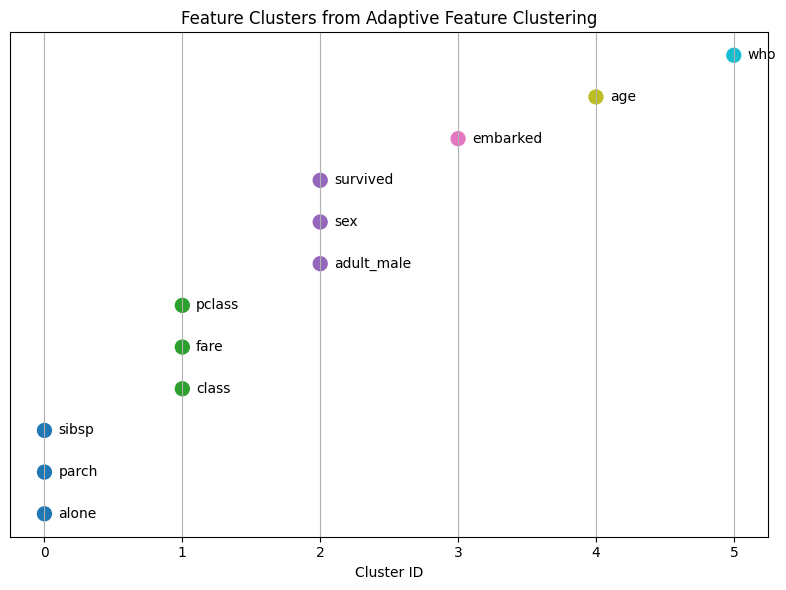

In [72]:
plot_feature_clusters(dict(sorted(features_clusters.items())))

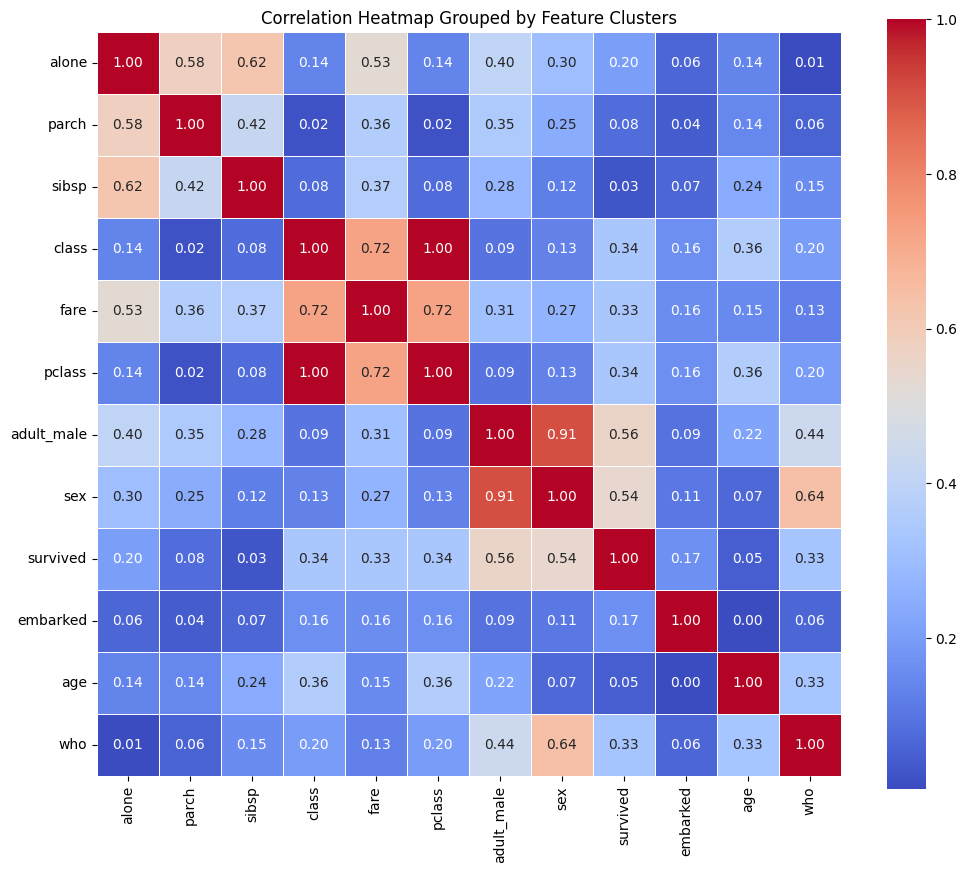

In [ ]:
# Reorder features based on cluster assignments
sorted_features = []
for cluster_id in sorted(features_clusters.keys()):
    sorted_features.extend(features_clusters[cluster_id])

# Reorder correlation matrix accordingly
corr_reordered = corr.loc[sorted_features, sorted_features]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_reordered, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar=True,
            linewidths=0.5)

plt.title('Correlation Heatmap Grouped by Feature Clusters')
plt.show()


C:\Users\Rudra\AppData\Local\Temp\ipykernel_21420\2277491965.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(features_clusters))


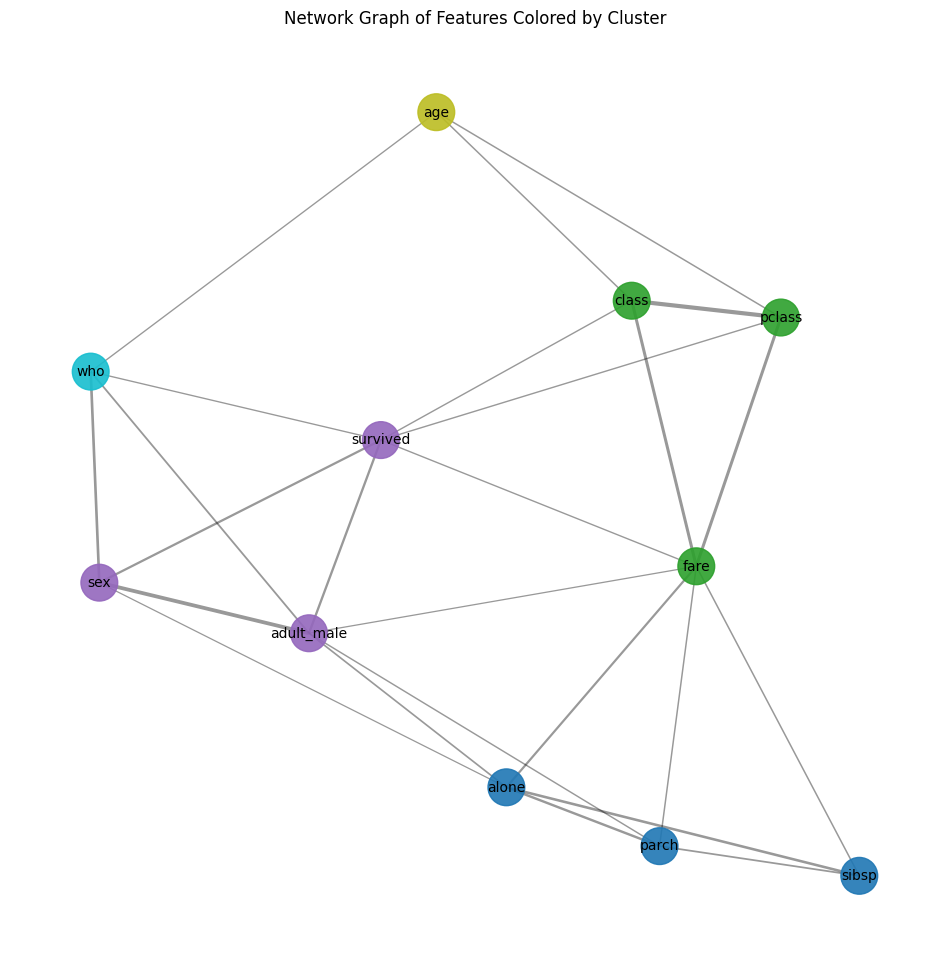

In [ ]:
import networkx as nx
import matplotlib.cm as cm

# Create graph from correlation matrix (threshold to keep edges meaningful)
threshold = 0.3
edges = []
for i, feat_i in enumerate(corr.columns):
    for j, feat_j in enumerate(corr.columns):
        if i < j and corr.loc[feat_i, feat_j] > threshold:
            edges.append((feat_i, feat_j, corr.loc[feat_i, feat_j]))

G = nx.Graph()
G.add_weighted_edges_from(edges)

# Assign cluster colors
cluster_color_map = {}
colors = cm.get_cmap('tab10', len(features_clusters))
for cluster_id, features in features_clusters.items():
    for f in features:
        cluster_color_map[f] = colors(cluster_id)

# Draw network graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)

node_colors = [cluster_color_map[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10)

# Draw edges with transparency proportional to weight
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, alpha=0.4, width=np.array(weights)*3)

plt.title('Network Graph of Features Colored by Cluster')
plt.axis('off')
plt.show()
